# Задача 1

Для датасета Mnist с рукописными цифрами:
1. Реализуйте модель классификации без сверточных слоев (только с полносвязными). Возьмите какое-нибудь изображение из датасета, реализуйте сдвиг этого изображения на 5px влево и вправо так, чтобы визуально объект на изображении смещался. Посчитайте вероятности для каждого класса. Визуализируйте как меняются вероятности в зависимости от степени сдвига.
2. Сделайте то же самое с сетью со сверточными слоями. Сравните результаты.

In [1]:
import requests
from io import BytesIO
from zipfile import ZipFile

# URL to the repository (modify this if the dataset is hosted in a specific location or file)
DATASET_URL = 'https://github.com/DeepTrackAI/MNIST_dataset/raw/main/mnist.zip'

response = requests.get(DATASET_URL)
with ZipFile(BytesIO(response.content)) as z:
    z.extractall()

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

In [16]:
# Загрузка и подготовка данных MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [17]:
# Нормализация данных (масштабирование в диапазон [0, 1])
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [18]:
# Преобразование формы данных для полносвязных слоев (выравнивание изображения)
x_train = x_train.reshape((60000, 28 * 28))
x_test = x_test.reshape((10000, 28 * 28))

In [19]:
# One-hot encoding для меток классов
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

In [20]:
model = models.Sequential([
    layers.Input(shape=(28 * 28,)),
    layers.Dense(512, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [21]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [22]:
epochs = 10
batch_size = 128
validation_split = 0.2

early_stopping = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history = model.fit(
    x_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=validation_split,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8528 - loss: 0.5132 - val_accuracy: 0.9571 - val_loss: 0.1530
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9639 - loss: 0.1271 - val_accuracy: 0.9682 - val_loss: 0.1111
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9759 - loss: 0.0828 - val_accuracy: 0.9699 - val_loss: 0.0975
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9839 - loss: 0.0575 - val_accuracy: 0.9721 - val_loss: 0.0878
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9889 - loss: 0.0412 - val_accuracy: 0.9749 - val_loss: 0.0819
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9934 - loss: 0.0283 - val_accuracy: 0.9752 - val_loss: 0.0822
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9947 - loss: 0.0224 - val_accuracy: 0.9766 - val_loss: 0.0812
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9970 - loss: 0.0154 - val_accu

Text(0.5, 1.0, 'Точность модели')

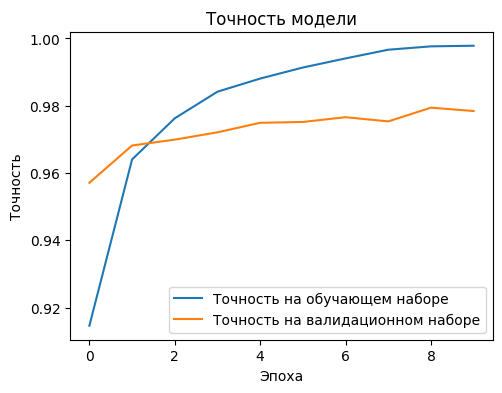

In [24]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Точность на обучающем наборе')
plt.plot(history.history['val_accuracy'], label='Точность на валидационном наборе')
plt.xlabel('Эпоха')
plt.ylabel('Точность')
plt.legend()
plt.title('Точность модели')

Text(0.5, 1.0, 'Потери модели')

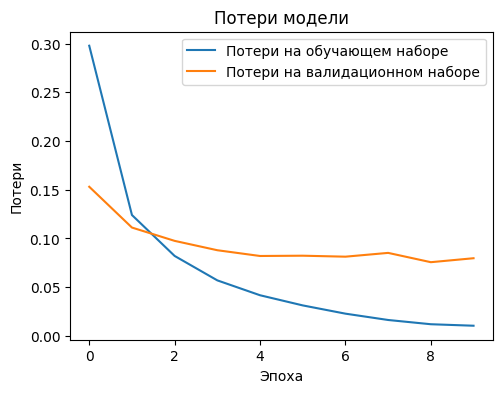

In [27]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Потери на обучающем наборе')
plt.plot(history.history['val_loss'], label='Потери на валидационном наборе')
plt.xlabel('Эпоха')
plt.ylabel('Потери')
plt.legend()
plt.title('Потери модели')

In [50]:
def shift_image(image, dx, dy):
    """Сдвигает изображение на dx пикселей вправо и dy пикселей вниз, заполняя нулями."""
    shifted_image = np.roll(image, shift=(dy, dx), axis=(0, 1))

    # Создаем маску для областей, которые нужно заполнить нулями
    mask = np.zeros_like(image, dtype=bool)
    if dx > 0:
        mask[:, :dx] = True
    elif dx < 0:
        mask[:, dx:] = True
    if dy > 0:
        mask[:dy, :] = True
    elif dy < 0:
        mask[dy:, :] = True

    shifted_image[mask] = 0

    return shifted_image

In [51]:
# Выбор случайного изображения из тестового набора
image_index = np.random.randint(0, len(x_test))
original_image = x_test[image_index].reshape(28, 28)

In [52]:
# Параметры сдвига
shifts = range(-5, 6)  # Сдвиги от -5 до 5 пикселей
probabilities = []

In [53]:
# Цикл сдвига и предсказания
for shift in shifts:
    # Сдвиг изображения
    shifted_image = shift_image(original_image, shift, 0) # сдвигаем только по x (влево/вправо)

    # Подготовка сдвинутого изображения для предсказания (выравнивание и добавление размерности батча)
    shifted_image_flat = shifted_image.reshape(1, 28 * 28)

    # Предсказание вероятностей классов
    predictions = model.predict(shifted_image_flat)
    probabilities.append(predictions[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


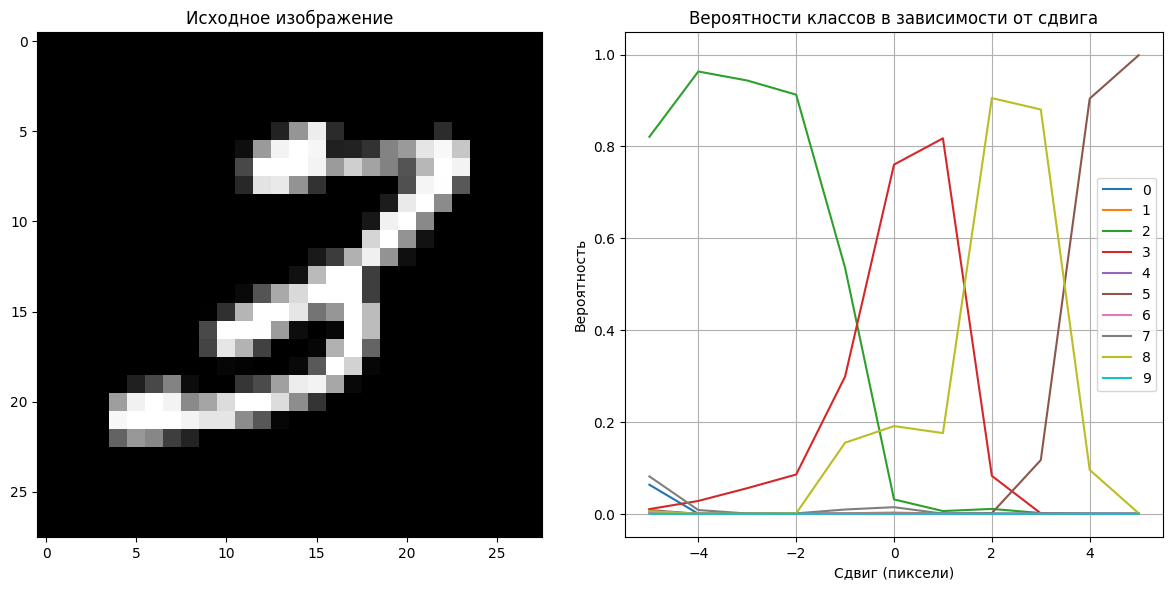

In [54]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(original_image, cmap='gray')
plt.title("Исходное изображение")

plt.subplot(1, 2, 2)
for i in range(10):
    plt.plot(shifts, [p[i] for p in probabilities], label=str(i))
plt.xlabel("Сдвиг (пиксели)")
plt.ylabel("Вероятность")
plt.title("Вероятности классов в зависимости от сдвига")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Исходное изображение: Модель уверена, что это "3" (зеленая линия имеет высокую вероятность около 0.8-1.0 при сдвиге 0).

Сдвиг влево (отрицательный): При сдвиге влево вероятность класса "3" уменьшается, а вероятность других классов (например, "2", "8") увеличивается. Это логично, так как сдвиг влево может изменить форму "3", делая ее более похожей на "2" или "8".

Сдвиг вправо (положительный): При сдвиге вправо вероятность класса "3" сначала немного уменьшается, а затем резко падает и сильно растёт класс "8".

Другие классы: Другие классы имеют низкую вероятность, когда изображение центрировано, но их вероятности увеличиваются при сдвиге, так как сдвиг искажает форму "3".

Выводы:

Чувствительность к сдвигу: График демонстрирует, что полносвязная сеть очень чувствительна к сдвигам. Даже небольшие сдвиги могут значительно изменить предсказанные вероятности классов. Это ожидаемо, так как полносвязные сети не обладают встроенной инвариантностью к сдвигам (в отличие от сверточных сетей).

Ограничения полносвязной сети: Этот эксперимент подчеркивает ограничения использования полносвязных сетей для задач распознавания изображений, где объекты могут появляться в разных местах изображения.

Улучшение устойчивости: Чтобы улучшить устойчивость к сдвигам, можно:

Использовать сверточные нейронные сети (CNN), которые обладают встроенной инвариантностью к сдвигам благодаря операциям свертки и пулинга.

Применить аугментацию данных, например, сдвигая тренировочные изображения случайным образом.

Тренировать модель на большем количестве данных.

# Задача 2

Напишите модель классификации на предобученной сети resnet18 на Pytorch с заменой последнего полносвязного слоя для данных из [директории](https://drive.google.com/drive/folders/1r0PvRCsrqBpRe6bj1aw8bLwkEfAbC9lo?usp=sharing). Построить графики обучения и потерь.

# Задача 3

Для [набора данных](https://drive.google.com/drive/folders/1sPwKGt_BX0fwGFTwVcoC7opwLT41b9Ug?usp=sharing) :
1. Изучить зависимость точности модели от разных размеров батча. Построить графики кривых обучения.
2. Изучить зависимость точности модели от разных оптимизаторов. Построить графики кривых обучения.